# FASE 3 (Cap. 1) - Relatório de Pipeline e Consultas Oracle

**Alunos:**
* Alan Robin Santos - RM567437
* Lucas Alberto da Silva Amorim - RM567505

## Relatório de Passos

Este relatório documenta os passos seguidos para a entrega da atividade.

### Passo 1: Carga dos Dados (ETL)

Os dados simulados dos sensores da FASE 2 (arquivo `sensores_simulados.csv`) foram carregados no banco de dados Oracle.

* **Ferramenta:** Oracle SQL Developer - Import Data Wizard.
* **Tabela de Destino:** `SENSORES` 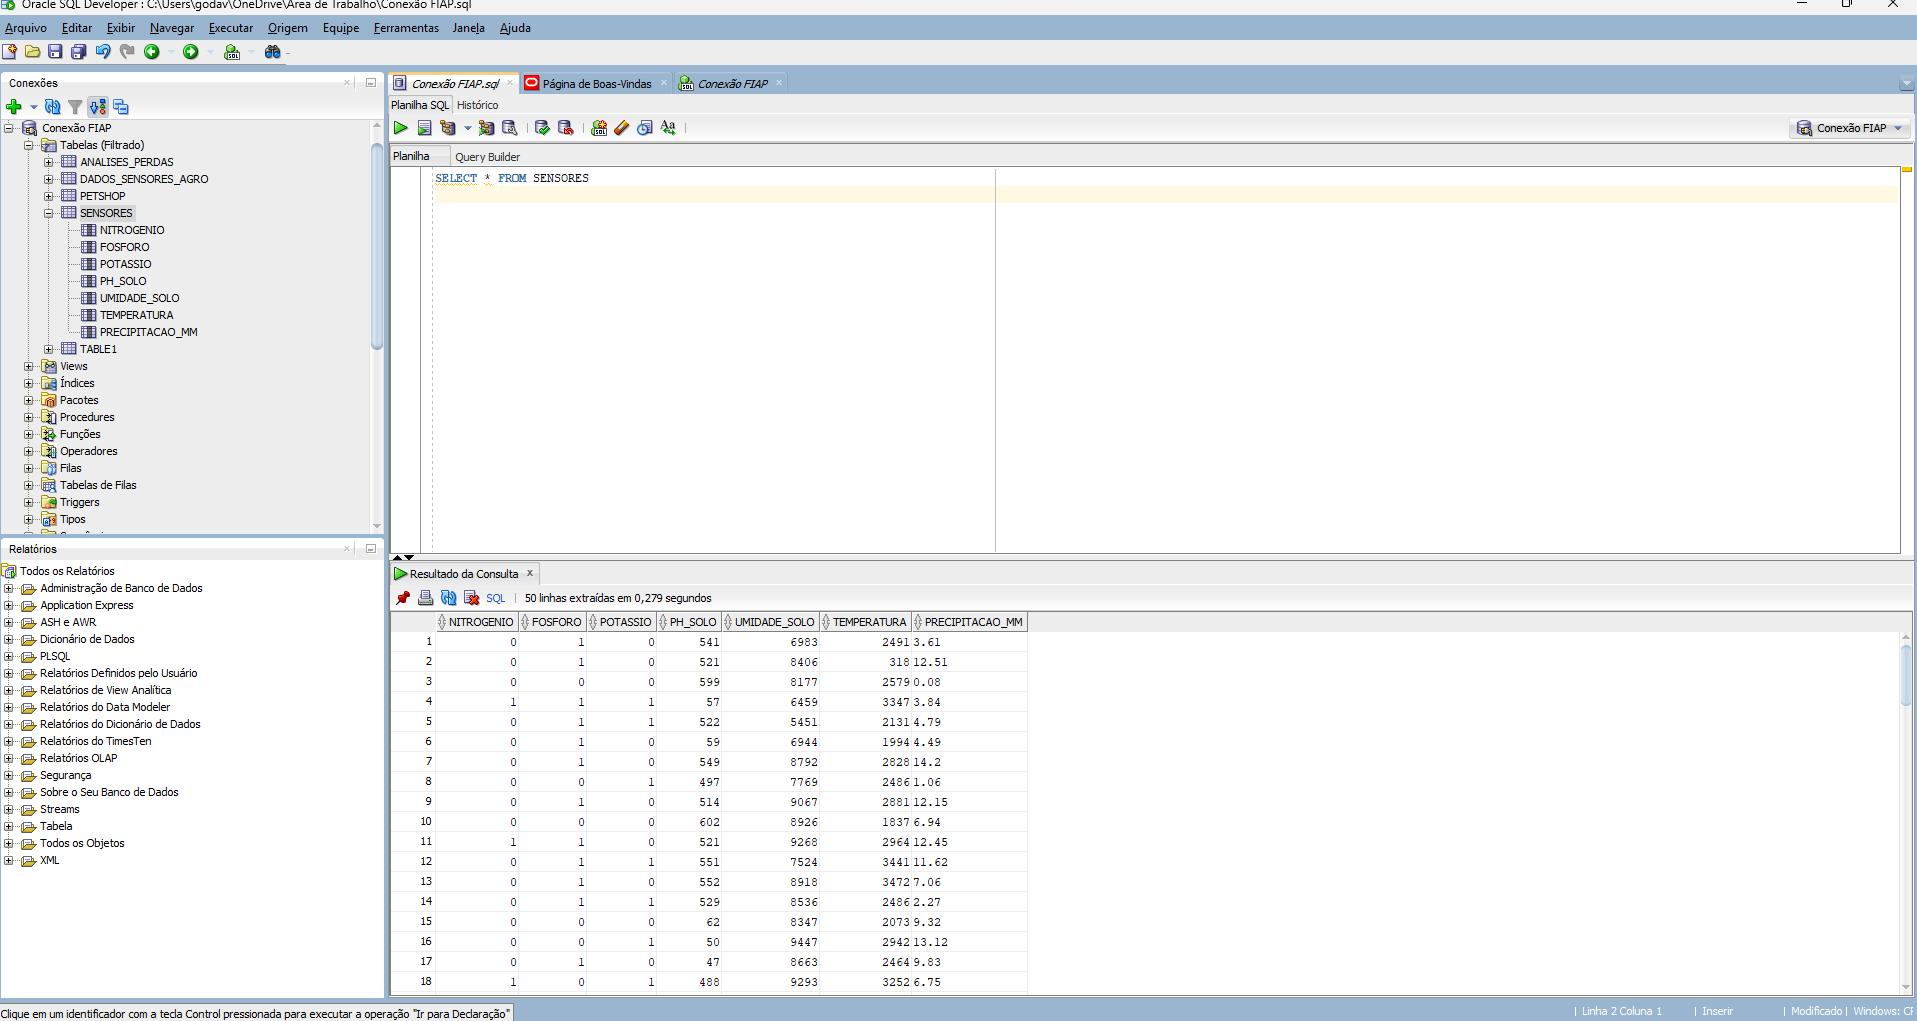.

### Passo 2: Preparação do Ambiente Python

A célula abaixo importa as bibliotecas necessárias (`pandas`, `oracledb`) e carrega as credenciais de conexão do arquivo `db_operations.py`.

In [9]:
import pandas as pd
import oracledb
import locale

# Configura o Python para mostrar números no formato brasileiro (ex: 10.000,00)
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except locale.Error:
    locale.setlocale(locale.LC_ALL, 'Portuguese_Brazil.1252')

# Importa as credenciais do nosso arquivo copiado
try:
    from db_operations import DB_USER, DB_PASSWORD, DB_DSN
    print("Bibliotecas Python importadas com sucesso.")
    print(f"Pronto para conectar ao Oracle com o usuário: {DB_USER}")
except ImportError:
    print("ERRO: O arquivo 'db_operations.py' não foi encontrado.")
    print("Por favor, copie o 'db_operations.py' da FASE 2 para esta pasta.")

Bibliotecas Python importadas com sucesso.
Pronto para conectar ao Oracle com o usuário: RM567437


## Passo 3: Consultas Realizadas

Abaixo estão as consultas SQL executadas diretamente no banco Oracle via Python, como solicitado.

In [10]:
# Define o nome da tabela que você criou no Oracle
NOME_DA_TABELA = "SENSORES"

# Lista de consultas obrigatórias
consultas = {
    "1. Contagem Total de Registros": f"SELECT COUNT(*) FROM {NOME_DA_TABELA}",
    "2. Ver os 5 Primeiros Registros": f"SELECT * FROM {NOME_DA_TABELA} WHERE ROWNUM <= 5",
    "3. Média de Temperatura e Umidade": f"SELECT ROUND(AVG(TEMPERATURA), 2) AS MEDIA_TEMP, ROUND(AVG(UMIDADE_SOLO), 2) AS MEDIA_UMIDADE FROM {NOME_DA_TABELA}",
    "4. Registros com pH Crítico (Ácido)": f"SELECT * FROM {NOME_DA_TABELA} WHERE PH_SOLO < 5.0"
}

print(f"--- Executando Consultas na Tabela '{NOME_DA_TABELA}' ---")

try:
    with oracledb.connect(user=DB_USER, password=DB_PASSWORD, dsn=DB_DSN) as connection:
        for nome, sql in consultas.items():
            print(f"\n--- {nome} ---")
            print(f"SQL: {sql}")

            # Usa o Pandas para ler o SQL e formatar a saída
            df_resultado = pd.read_sql(sql, connection)

            print("Resultado (Print da Consulta):")
            print(df_resultado.to_string(index=False)) # .to_string() formata bem no output
            print("-" * 50)

    print("\nConsultas obrigatórias concluídas com sucesso.")

except Exception as e:
    print(f"ERRO AO CONSULTAR: {e}")
    print("Verifique se o nome da tabela está correto e se as colunas existem.")

--- Executando Consultas na Tabela 'SENSORES' ---

--- 1. Contagem Total de Registros ---
SQL: SELECT COUNT(*) FROM SENSORES
Resultado (Print da Consulta):
 COUNT(*)
     1000
--------------------------------------------------

--- 2. Ver os 5 Primeiros Registros ---
SQL: SELECT * FROM SENSORES WHERE ROWNUM <= 5


C:\Users\godav\AppData\Local\Temp\ipykernel_12468\1154774103.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resultado = pd.read_sql(sql, connection)
C:\Users\godav\AppData\Local\Temp\ipykernel_12468\1154774103.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resultado = pd.read_sql(sql, connection)


Resultado (Print da Consulta):
 NITROGENIO  FOSFORO  POTASSIO  PH_SOLO  UMIDADE_SOLO  TEMPERATURA PRECIPITACAO_MM
          0        1         0      541          6983         2491            3.61
          0        1         0      521          8406          318           12.51
          0        0         0      599          8177         2579            0.08
          1        1         1       57          6459         3347            3.84
          0        1         1      522          5451         2131            4.79
--------------------------------------------------

--- 3. Média de Temperatura e Umidade ---
SQL: SELECT ROUND(AVG(TEMPERATURA), 2) AS MEDIA_TEMP, ROUND(AVG(UMIDADE_SOLO), 2) AS MEDIA_UMIDADE FROM SENSORES
Resultado (Print da Consulta):
 MEDIA_TEMP  MEDIA_UMIDADE
    2423.15        6974.75
--------------------------------------------------

--- 4. Registros com pH Crítico (Ácido) ---
SQL: SELECT * FROM SENSORES WHERE PH_SOLO < 5.0
Resultado (Print da Consulta):
Empt

C:\Users\godav\AppData\Local\Temp\ipykernel_12468\1154774103.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resultado = pd.read_sql(sql, connection)
C:\Users\godav\AppData\Local\Temp\ipykernel_12468\1154774103.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resultado = pd.read_sql(sql, connection)


## 4. Conclusão

O relatório foi concluído. Os dados foram carregados no Oracle (Passo 1, via GUI) e as consultas de verificação (Passo 3, via Python) foram executadas com sucesso, conforme demonstrado nos "prints" (saídas de célula) acima.